In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import transforms, models

In [4]:
from PIL import Image
import os
import pandas as pd
from time import time
import gc
import numpy as np
import shutil
import copy
import re

In [3]:
from transformers import DistilBertConfig, DistilBertTokenizer, DistilBertModel, get_cosine_schedule_with_warmup
# , BertModel, BertTokenizer
from sklearn.model_selection import  train_test_split

In [5]:
seed = 19971204
torch.manual_seed(seed)
np.random.seed(seed)
# for cuda
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

In [6]:
class MultiModalDataset(Dataset):

    def __init__(self, csv_file, root_dir, transform=None):
        
        self.dataframe = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        self.tokenised_sentences = bertTokens(self.dataframe)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_name = os.path.join(self.root_dir,
                                self.dataframe.iloc[idx, 15])

        image = Image.open(img_name)
        image = self.transform(image)

        sent_id = torch.tensor(self.tokenised_sentences[0][idx])
        attn = torch.tensor(self.tokenised_sentences[1][idx])

        label = self.dataframe.iloc[idx, 8]
        label = torch.tensor(label)

        sample = (sent_id, attn, image, label)

        return sample

In [7]:
model_class, tokenizer_class, pretrained_weights, config_class = (DistilBertModel, DistilBertTokenizer, 'distilbert-base-uncased', DistilBertConfig)
# model_class, tokenizer_class, pretrained_weights = (BertModel, BertTokenizer, 'bert-base-uncased')

tokenizer = tokenizer_class.from_pretrained(pretrained_weights)

In [8]:
preprocess = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [9]:
def preprocess_text(sen):

    # Remove punctuations and numbers
    sentence = re.sub('[^a-zA-Z]', ' ', sen)

    # Single character removal
    sentence = re.sub(r"\s+[a-zA-Z]\s+", ' ', sentence)

    # Removing multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)

    sentence = sentence.lower()

    return sentence

In [10]:
def bertTokens(textDataset):

    max_len=256

    at_sentences = textDataset['at']
    mwes = textDataset['mwe']

    # sentences = ['.'.join([mwe, preprocess_text(sent)]) for mwe, sent in list(zip(mwes, at_sentences))]
    
    tokenized = [tokenizer.encode(mwe, sent, add_special_tokens=True) for mwe, sent in list(zip(mwes, at_sentences))]

    # sentences = [preprocess_text(x) for x in textDataset['at']]
    # sentence = preprocess_text(input_sentence)

    # tokenized = [tokenizer.encode(x, add_special_tokens=True) for x in sentences]
    # tokenized = sentences.apply((lambda x: tokenizer.encode(x, add_special_tokens=True)))

    # tokenized = tokenizer.encode_plus(
    #         text=sentence, 
    #         add_special_tokens=True,
    #     #     max_length = 174,  # maximum length of a sentence = 174
    #         padding='longest',  
    #         return_attention_mask = True,
    #         return_tensors = 'pt', 
    #         )

    # input_ids = tokenized['input_ids']
    # attention_mask = tokenized['attention_mask']

    # max_len = 0 
    # for i in tokenized:
    #     if len(i) > max_len:
    #         max_len = len(i)

    input_ids = np.array([i + [0]*(max_len-len(i)) for i in tokenized])

    attention_mask = np.where(input_ids != 0, 1, 0)

    return input_ids, attention_mask

In [11]:
multimodaldataset = MultiModalDataset(csv_file='../dataset/text/multimodal_train_json.csv',
                                 root_dir='../dataset/scenario3/classes',
                                 transform=preprocess)

In [12]:
RATIO=0.9

multi_len = len(multimodaldataset)

n_temp_examples = int(multi_len * RATIO)
n_test_examples = multi_len - n_temp_examples


temp_data, test_data  = random_split(multimodaldataset, 
                                           [n_temp_examples, n_test_examples])


n_train_examples = int(len(temp_data) * RATIO)
n_valid_examples = len(temp_data) - n_train_examples

train_data, valid_data = random_split(temp_data, 
                                [n_train_examples, n_valid_examples])

len(train_data), len(test_data), len(valid_data)

(2519, 311, 280)

In [13]:
BATCH_SIZE = 4

train_dataloader = DataLoader(train_data, 
                                 shuffle = True, 
                                 batch_size = BATCH_SIZE)

valid_dataloader = DataLoader(valid_data, 
                                 batch_size = BATCH_SIZE)

test_dataloader = DataLoader(test_data, 
                                batch_size = BATCH_SIZE)

In [14]:
class ModifiedInception(nn.Module):
    def __init__(self, image_model):
        super(ModifiedInception, self).__init__()
        self.image_model = image_model
        self.image_regr1 = nn.Linear(1024, 256)

        self.relu = nn.ReLU()

    def forward(self, image, train_eval):
        if not train_eval:
            inception_output, _ = self.image_model(image)
        else:
            inception_output = self.image_model(image)
        image_features = self.relu(self.image_regr1(inception_output))
        return image_features

In [15]:
class BERT_CNN(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        
        self.relu = nn.ReLU()    
        self.text_regr1 = nn.Linear(hidden_size, 256)
        self.text_regr2 = nn.Linear(256, 256)

    def forward(self, outputs):
        #Feed the input to Bert model to obtain contextualized representations
        # outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        #Obtain the representations of [CLS] heads
        logits = outputs.last_hidden_state[:,0,:]
        output = self.relu(self.text_regr1(logits))
        text_features = self.relu(self.text_regr2(output))
        return text_features

In [16]:
class MultiModalFramework(nn.Module):
    def __init__(self, image_model, hidden_size):
        super().__init__()
        
        self.modifiedInception = ModifiedInception(image_model)
        self.bert_cnn = BERT_CNN(hidden_size)

        self.combined_regr = nn.Linear(512, 2)
        self.softmax = nn.LogSoftmax(dim=1)
        
    def forward(self, text_inputs, image, train_eval):
        image_features = self.modifiedInception(image, train_eval)
        text_features = self.bert_cnn(text_inputs)

        combined_input = torch.cat((image_features, text_features), 1)
        combined_output = self.softmax(self.combined_regr(combined_input))

        return combined_output

In [17]:
inceptionModel = models.inception_v3(pretrained=True)

IN_FEATURES = inceptionModel.fc.in_features 
OUTPUT_DIM = 1024

fc = nn.Linear(IN_FEATURES, OUTPUT_DIM)
inceptionModel.fc = fc

In [ ]:
config = config_class.from_pretrained(pretrained_weights, output_attentions=True)
bertModel = model_class.from_pretrained(pretrained_weights, config=config) 

In [19]:
multiModalFramework = MultiModalFramework(inceptionModel, config.hidden_size)

optimizer = optim.Adam(multiModalFramework.parameters(), lr=1e-5)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

criterion = nn.CrossEntropyLoss()

multiModalFramework = multiModalFramework.to(device)
criterion = criterion.to(device)
bertModel = bertModel.to(device)

In [19]:
# del multiModalFramework
# del criterion
# gc.collect()
# torch.cuda.empty_cache()

In [20]:
NUM_EPOCHS=5
num_training_steps = NUM_EPOCHS+2
num_warmup_steps = 2

scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=num_warmup_steps, 
    num_training_steps=num_training_steps)

In [21]:
def train_model(model, dataloader):
    
    model.train()  # Set model to training mode
    
    running_loss = 0.0
    running_corrects = 0

    # Iterate over data.
    for i, batch in enumerate(dataloader):
        # push the batch to gpu
        batch = [r.to(device) for r in batch]
        sent_id, mask, image, labels = batch
        del batch
        gc.collect()
        torch.cuda.empty_cache()

        # zero the parameter gradients
        optimizer.zero_grad()

        # with torch.no_grad():
        inputs = bertModel(sent_id, attention_mask=mask)
            
        outputs = model(inputs, image, 0)
        # compute the loss between actual and predicted values
        loss = criterion(outputs, labels)
        
        _, preds = torch.max(outputs, 1)

        # backward + optimize only if in training phase
        loss.backward()
        optimizer.step()
        scheduler.step()

        # statistics
        running_loss += float(loss.item())
        running_corrects += torch.sum(preds == labels.data)

    return running_loss, running_corrects

In [22]:
def evaluate_model(model, dataloader):
    
    model.eval()

    running_loss = 0.0
    running_corrects = 0

    for i, batch in enumerate(dataloader):
        # push the batch to gpu
        batch = [r.to(device) for r in batch]
        sent_id, mask, image, labels = batch
        del batch
        gc.collect()
        torch.cuda.empty_cache()

        with torch.no_grad():
            inputs = bertModel(sent_id, attention_mask=mask)
            outputs = model(inputs, image, 1)
            
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

        # statistics
        running_loss += float(loss.item())
        running_corrects += torch.sum(preds == labels.data)

    return running_loss, running_corrects

In [23]:
best_valid_loss = float('inf')

best_model_wts = copy.deepcopy(multiModalFramework.state_dict())
best_acc = 0.0

train_length = len(train_data)
val_length = len(valid_data)

train_losses = []
val_losses = []
train_accuracies=[]
valid_accuracies=[]


In [24]:
since = time()

for epoch in range(NUM_EPOCHS):
        print('Epoch {}/{}'.format(epoch + 1, NUM_EPOCHS))
        print('-' * 10)
        print('Training...')
        print(f'With lr: {optimizer.param_groups[0]["lr"]:.8f}')

        train_loss, train_acc = train_model(multiModalFramework, train_dataloader)
        training_loss = train_loss / train_length
        training_acc = train_acc.double() / train_length
        print('Training Loss: {:.4f} Acc: {:.4f}'.format(training_loss, training_acc))

        print('Evaluating..')
        val_loss, val_acc = evaluate_model(multiModalFramework, valid_dataloader)
        val_loss = val_loss / val_length
        val_acc = val_acc.double() / val_length
        
        print('Validation Loss: {:.4f} Acc: {:.4f}'.format(val_loss, val_acc))

        if val_loss > best_valid_loss:
                best_model_wts = copy.deepcopy(multiModalFramework.state_dict())
                print('Early stopping as {} > {}'.format(val_loss, best_valid_loss))
                break
        else:
                best_valid_loss = val_loss
                best_acc = val_acc

        
        train_losses.append(training_loss)
        val_losses.append(val_loss)
        train_accuracies.append(training_acc)
        valid_accuracies.append(val_acc)
        print()

time_elapsed = time() - since
print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
print('Best val Acc: {:4f}'.format(best_acc))

# load best model weights
# model.load_state_dict(best_model_wts)

Epoch 1/5
----------
Training...
With lr: 0.00000000


D:\anaconda3\lib\site-packages\torch\nn\functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  ..\c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


Training Loss: 0.1680 Acc: 0.5863
Evaluating..
Validation Loss: 0.1606 Acc: 0.6321

Epoch 2/5
----------
Training...
With lr: 0.00000655
Training Loss: 0.1606 Acc: 0.6098
Evaluating..
Validation Loss: 0.1518 Acc: 0.6857

Epoch 3/5
----------
Training...
With lr: 0.00000655
Training Loss: 0.1437 Acc: 0.7058
Evaluating..
Validation Loss: 0.1410 Acc: 0.7143

Epoch 4/5
----------
Training...
With lr: 0.00000655
Training Loss: 0.1208 Acc: 0.7829
Evaluating..
Validation Loss: 0.1346 Acc: 0.7143

Epoch 5/5
----------
Training...
With lr: 0.00000655
Training Loss: 0.1034 Acc: 0.8241
Evaluating..
Validation Loss: 0.1398 Acc: 0.7071
Early stopping as 0.1398325011666332 > 0.1346082660236529
Training complete in 31m 59s
Best val Acc: 0.714286


In [115]:
torch.save(best_model_wts, 'weights/20210922_final_combined_saved_weights.pth')

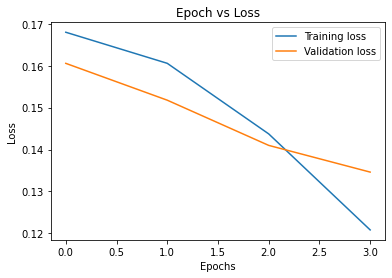

In [25]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Epoch vs Loss')
plt.legend()
plt.show()

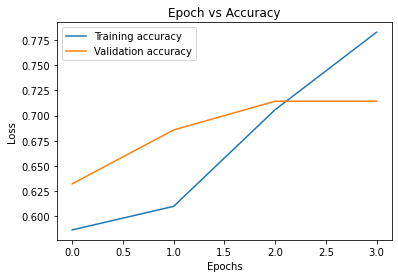

In [27]:
plt.plot(train_accuracies, label='Training accuracy')
plt.plot(valid_accuracies, label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Epoch vs Accuracy')
plt.legend()
plt.show()

In [28]:
predicted=[]
actuals=[]

multiModalFramework.eval()

with torch.no_grad():
        for i, batch in enumerate(test_dataloader):

            # push the batch to gpu
            batch = [t.to(device) for t in batch]

            sent_id, mask, image, labels = batch

            del batch
            gc.collect()
            torch.cuda.empty_cache()

            inputs = bertModel(sent_id, attention_mask=mask)
            outputs = multiModalFramework(inputs, image, 1)
            # _, preds = torch.max(outputs, 1)

            preds = outputs.detach().cpu().numpy()
            predicted.extend(preds)
            actuals.extend(labels.detach().cpu().numpy())

In [53]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

classes = ['Idiomatic', 'Literal']

print("Performance:")
preds = np.argmax(predicted, axis=1)
# model's performance/
print('Classification Report')
print(classification_report(actuals, preds, target_names=classes))

print("Accuracy: " + str(accuracy_score(actuals, preds)))
print("Precision: " + str(precision_score(actuals, preds)))
print("Recall: " + str(recall_score(actuals, preds)))
print("F1 score: " + str(f1_score(actuals, preds, average='macro')))

Performance:
Classification Report
              precision    recall  f1-score   support

   Idiomatic       0.86      0.70      0.77       178
     Literal       0.67      0.84      0.75       133

    accuracy                           0.76       311
   macro avg       0.76      0.77      0.76       311
weighted avg       0.78      0.76      0.76       311

Accuracy: 0.7588424437299035
Precision: 0.6746987951807228
Recall: 0.8421052631578947
F1 score: 0.7584828685919007


In [114]:
# from random import randint

# idxs = [randint(0, len(testDataset)) for i in range(10)]

# print(idxs)

pred_sent = []

for i in range(0, 10):

    sent = test_data[i][0].numpy()
    sent = tokenizer.decode(sent, skip_special_tokens=True)
    pred_sent.append(sent)
    print(sent)
    act_cla = 'Idiomatic' if not actuals[i] else 'Literal'
    print('Actual: ', act_cla)
    pre_cla = 'Idiomatic' if not preds[i] else 'Literal'
    print('Predicted: ', percent[i], '% ', pre_cla)

    print('-' * 10)

lip service even worse, it shows that their adherence to the international holocaust remembrance alliance ’ s definition of the term, which has been accepted by the biden administration as well as dozens of other governments, is mere lip service.
Actual:  Idiomatic
Predicted:  63.0 %  Literal
----------
law firm kirkland has raked in the top spot in the am law rankings three years in a row, and is the highest grossing law firm in the world at more than $ 4 billion in gross revenue in fiscal year 2019, according to the american lawyer.
Actual:  Literal
Predicted:  84.47 %  Literal
----------
cocktail dress otherwise, wear a skirted suit, cocktail dress with jacket or a long - sleeved, knee - length dress.
Actual:  Idiomatic
Predicted:  92.85 %  Idiomatic
----------
speed trap a speed trap is unethically extracting money from someone because the victim has no power.
Actual:  Idiomatic
Predicted:  95.42 %  Idiomatic
----------
field work never previously drilled or systematically explored

In [33]:
test_tuples = list(zip(*test_data))
sentences = []
mwes = []

for tokens in list(test_tuples[0]):
    sent = tokenizer.decode(tokens, skip_special_tokens=True)
    mwe = ' '.join(sent.split()[:2])
    mwes.append(mwe)
    sentences.append(sent)

In [ ]:
frequent_senses = pd.read_csv('../dataset/text/imageSenses.csv', converters={'frequent_sense': eval})

freq_sense = [list(x) for x in frequent_senses['frequent_sense']]

len(freq_sense)

In [60]:
freq_sense_test = []

for mwe in mwes:

    for i, row in frequent_senses.iterrows():
        if row['mwe'] == mwe:
            freq_sense_test.append(freq_sense[i])

In [110]:
pd.set_option('max_rows', 15)

In [ ]:
expo = torch.exp(torch.tensor(predicted))
percentages, _ = torch.max(expo, 1)

percent = [round(pc.item() * 100, 2) for pc in percentages]

In [111]:
dic = {'mwe':mwes, 'frequent sense':freq_sense_test, 'actual':actuals, 'predicted':preds, 'percentages': percent}

freq_sense_eval = pd.DataFrame(data=dic)

freq_sense_eval = freq_sense_eval.sort_values(by=['predicted', 'percentages'], ascending=False)

# freq_sense_eval.values.tolist()
freq_sense_eval

,mwe,frequent sense,actual,predicted,percentages
92,rush hour,[1],1,1,95.22
252,information age,[1],1,1,94.70
136,medical procedure,[1],1,1,92.39
231,polo shirt,[1],1,1,91.46
299,traffic control,[1],1,1,91.00
...,...,...,...,...,...
292,love song,[1],1,0,52.34
14,bank account,[1],1,0,52.25
17,spelling bee,[1],1,0,52.01
218,grass root,"[0, 1]",0,0,51.42
